In [1]:
# Step 1: Install and Import Libraries
from prophet import Prophet
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import requests
from datetime import datetime
import time
import warnings
warnings.simplefilter("ignore", category=FutureWarning)

/home/oadewusi/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# Step 2: Load and Process Data
github_url = "https://raw.githubusercontent.com/olusecc/CTFChallenge/refs/heads/main/boutique.json"

try:
    # Load data
    response = requests.get(github_url)
    response.raise_for_status()
    data = response.json()
    
    # Create initial dataframe
    df = pd.DataFrame(data['data']['result'][0]['values'])
    df.columns = ['ds', 'y']
    
    # Convert timestamps and values
    df['ds'] = pd.to_datetime(df['ds'], unit='s')
    df['y'] = df['y'].astype(float)
    df.dropna(inplace=True)  # Remove NaN values
    
    print("Data sample:")
    print(df.head())
    
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Data sample:
                   ds         y
0 2024-11-20 23:59:00  3.181250
1 2024-11-20 23:59:30  3.494737
2 2024-11-21 00:00:00  3.536842
3 2024-11-21 00:00:30  3.437018
4 2024-11-21 00:01:00  3.456140


In [3]:
# Step 3: Train Prophet Model
try:
    model = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    model.add_seasonality(name='hourly', period=7200, fourier_order=5)
    model.fit(df)
except Exception as e:
    print(f"Error in model fitting: {e}")

00:30:58 - cmdstanpy - INFO - Chain [1] start processing
00:30:58 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
# Step 4: Make Predictions
future = model.make_future_dataframe(periods=30, freq='30S')
forecast = model.predict(future)

# Create Performance DataFrame
performance = pd.DataFrame({
    'ds': df['ds'],
    'y': df['y'],
    'yhat': forecast['yhat'][-len(df):],
    'yhat_lower': forecast['yhat_lower'][-len(df):],
    'yhat_upper': forecast['yhat_upper'][-len(df):]
})

In [5]:
# Step 5: Add Anomaly Detection
performance['anomaly'] = 0
performance.loc[performance['y'] > performance['yhat_upper'], 'anomaly'] = 1
performance.loc[performance['y'] < performance['yhat_lower'], 'anomaly'] = 1

# Print anomaly statistics
print("\nAnomaly Statistics:")
print(performance['anomaly'].value_counts())
print("\nExample Anomalies:")
print(performance[performance['anomaly'] == 1].head())


Anomaly Statistics:
anomaly
0    123
1      9
Name: count, dtype: int64

Example Anomalies:
                    ds         y      yhat  yhat_lower  yhat_upper  anomaly
43 2024-11-21 00:21:30  3.894309  3.295160    2.880521    3.711543        1
44 2024-11-21 00:22:00  4.060109  3.294103    2.886984    3.687287        1
45 2024-11-21 00:22:30  4.262537  3.293045    2.891345    3.688627        1
46 2024-11-21 00:23:00  3.852547  3.291988    2.904711    3.693914        1
81 2024-11-21 00:41:30  4.016949  3.252783    2.860993    3.672623        1


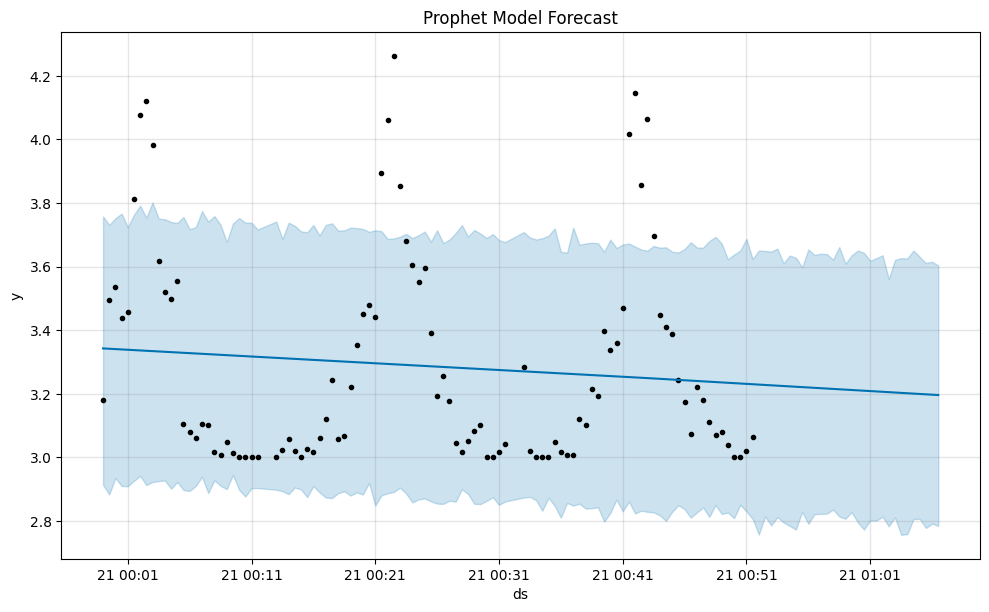

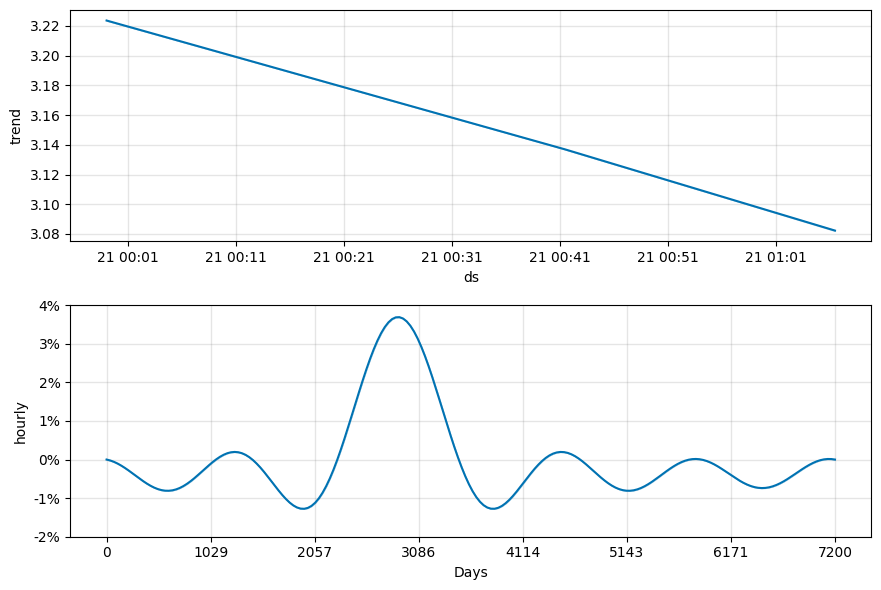

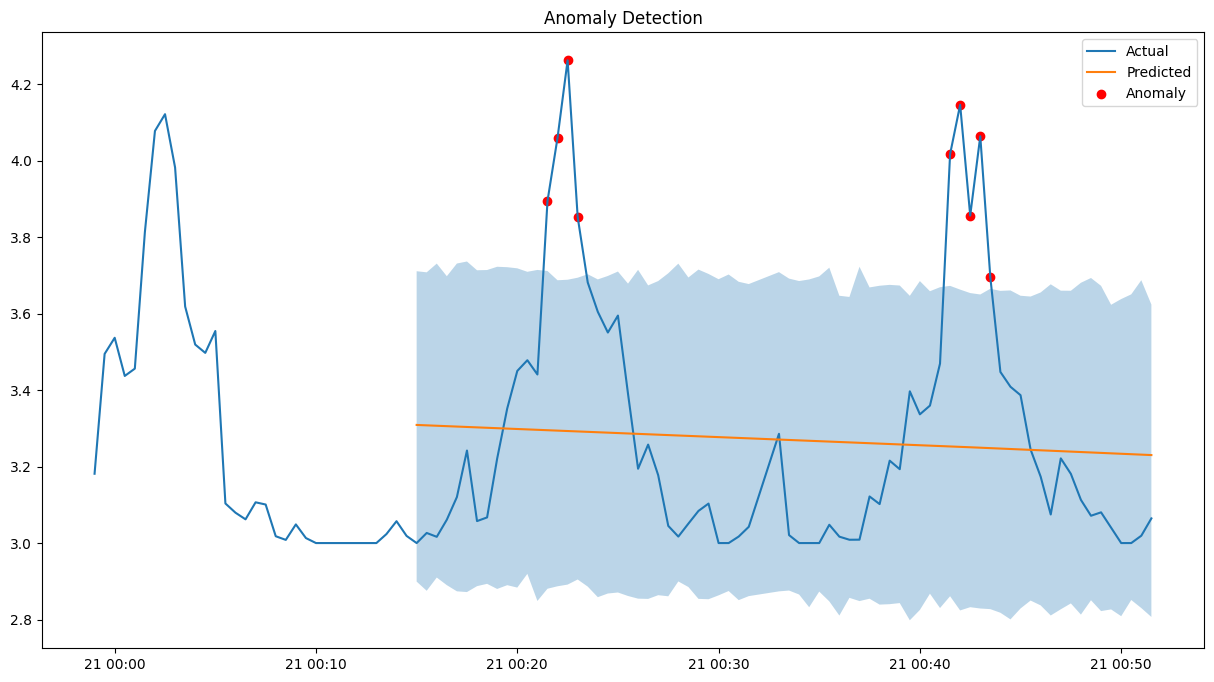

In [6]:
# Step 6: Visualize Results
# Plot 1: Forecast
fig1 = model.plot(forecast)
plt.title('Prophet Model Forecast')
plt.show()

# Plot 2: Components
fig2 = model.plot_components(forecast)
plt.show()

# Plot 3: Anomalies
plt.figure(figsize=(15, 8))
plt.plot(performance['ds'], performance['y'], label='Actual')
plt.plot(performance['ds'], performance['yhat'], label='Predicted')
plt.fill_between(
    performance['ds'],
    performance['yhat_lower'],
    performance['yhat_upper'],
    alpha=0.3
)
plt.scatter(
    performance[performance['anomaly'] == 1]['ds'],
    performance[performance['anomaly'] == 1]['y'],
    color='red',
    label='Anomaly'
)
plt.legend()
plt.title('Anomaly Detection')
plt.show()

In [7]:
performance = performance.dropna()  # Remove any potential NaN rows

# Convert columns to numeric if they aren't already
performance['y'] = pd.to_numeric(performance['y'], errors='coerce')
performance['yhat'] = pd.to_numeric(performance['yhat'], errors='coerce')

# Drop any rows where either y or yhat is NaN after conversion
performance = performance.dropna(subset=['y', 'yhat'])

# Now calculate metrics
mae = mean_absolute_error(performance['y'], performance['yhat'])
mape = mean_absolute_percentage_error(performance['y'], performance['yhat'])

# Print metrics
print("\nPerformance Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")



Performance Metrics:
MAE: 0.2489
MAPE: 0.0729
